## Predicting image labels on the CIFAR-10 dataset with MindSpore

_This notebook experiment is a revised version of [donaldsebleung/cifar10-mindspore](https://gitcode.com/donaldsebleung/cifar10-mindspore) on GitCode._

In this article, we'll train a linear classification model to predict image labels on the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset with MindSpore.

The software versions used are listed below.

1. Python 3.12
1. MindSpore 2.8.0
1. CANN 8.5.0 - on Ascend platform only
1. Matplotlib 3.10.8

In [1]:
%pip install -r requirements.txt


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Here's a high-level overview of our approach in this notebook experiment.

1. Load and preprocess the data
    1. Load the training and validation sets
    1. Resize each image to $32\times32$ pixels
    1. Rescale each channel \(RGB\) per pixel per image from integer in range $[0,255]$ to float in range $[0,1]$
    1. Flatten each image $32\times32\times3=3072$ input features
    1. Apply one-hot encoding to the labels
    1. Visualize a few samples from our training set
1. Define our neural network as a single fully-connected layer with $3072$ input channels and $10$ output channels
1. Define our combined activation and loss function as [`mindspore.nn.SoftmaxCrossEntropyWithLogits`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.SoftmaxCrossEntropyWithLogits.html)
1. Define our minibatch SGD optimizer with carefully selected hyperparameters
    1. Learning rate $\eta$
    1. Weight decay $\lambda$
    1. Momentum $\mu$
1. Define our forward and gradient functions
1. Define the training logic for each batch and epoch
1. Define the validation logic and compute the loss at the end of each epoch
1. Start the training and validation process
1. Plot the training vs. validation loss with Matplotlib
1. Compute the final validation accuracy of our model
1. Export the model to MindIR format

Before proceeding, let's initialize MindSpore and confirm it is successfully installed.

In [2]:
import os

NOTEBOOK_USE_ASCEND = os.getenv('NOTEBOOK_USE_ASCEND', '0')
NOTEBOOK_USE_GPU = os.getenv('NOTEBOOK_USE_GPU', '0')
NOTEBOOK_USE_CPU = os.getenv('NOTEBOOK_USE_CPU', '0')
NOTEBOOK_CI_MODE = os.getenv('NOTEBOOK_CI_MODE', '0')

In [3]:
import mindspore

platform = 'Ascend'
if NOTEBOOK_USE_ASCEND == '1':
    platform = 'Ascend'
elif NOTEBOOK_USE_GPU == '1':
    platform = 'GPU'
elif NOTEBOOK_USE_CPU == '1' or NOTEBOOK_CI_MODE == '1':
    platform = 'CPU'
else:
    platform = 'Ascend'

mindspore.set_device(device_target=platform)
mindspore.run_check()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

MindSpore version:  2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!


Feel free to ignore any warning messages except for those starting with `[ERROR]` or `[CRITICAL]`, in which case consult the Ascend forum. If MindSpore 2.8.0 is installed successfully, you should see a message similar to the one below.

```text
MindSpore version: 2.8.0
The result of multiplication calculation is correct, MindSpore has been installed on platform [Ascend] successfully!
```

## Loading and preprocessing the data

MindSpore 2.8.0 provides the built-in [`mindspore.dataset.Cifar10Dataset`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/dataset/mindspore.dataset.Cifar10Dataset.html) class for loading the CIFAR-10 dataset. It assumes the data is already downloaded to the directory specified by `dataset_dir` in binary form.

In [4]:
dataset_dir = 'data/'

os.makedirs(dataset_dir, exist_ok=True)

In [5]:
import tarfile
import urllib.request

cifar10_url = 'https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz'

with urllib.request.urlopen(cifar10_url) as response:
    with tarfile.open(fileobj=response, mode='r|gz') as tar:
        tar.extractall(path=dataset_dir, filter='data')

dataset_dir = os.path.join(dataset_dir, 'cifar-10-batches-bin/')
dataset_dir

'data/cifar-10-batches-bin/'

Let's load the training and validation data separately.

In [6]:
import mindspore.dataset as ds

train_ds = ds.Cifar10Dataset(dataset_dir=dataset_dir, usage='train', shuffle=True)
test_ds = ds.Cifar10Dataset(dataset_dir=dataset_dir, usage='test', shuffle=True)

Apply the following transformations to image in both our training and validation sets.

1. Resize each image to $32 \times 32$ pixels. This should already be the case but let's play it safe ;-\)
1. Rescale each channel from integer in range $[0, 255]$ to float in range $[0, 1]$
1. Use [`mindspore.dataset.vision.HWC2CHW`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/dataset_vision/mindspore.dataset.vision.HWC2CHW.html) to change the shape of each image from `(height, width, channels)` to `(channels, height, width)`. This is unnecessary for our use case of feeding the image directly to our fully connected layer but will be useful when dealing with convolutions in future notebook experiments

Furthermore, apply one-hot encoding to labels in both our training and validation sets. One-hot encoding is especially well-suited for classification tasks.

In [7]:
import mindspore.dataset.vision as vision
import mindspore.dataset.transforms as transforms

def transform_ds(dataset):
    image_transforms = [
        vision.Resize(size=(32, 32)),
        vision.Rescale(rescale=1/255, shift=0),
        vision.HWC2CHW()
    ]
    label_transforms = [
        transforms.OneHot(num_classes=10)
    ]
    dataset = dataset.map(operations=image_transforms, input_columns='image')
    dataset = dataset.map(operations=label_transforms, input_columns='label')
    return dataset

train_ds, test_ds = transform_ds(dataset=train_ds), transform_ds(dataset=test_ds)

Batch our training data in multiples of $2^9=512$ samples.

In [8]:
train_ds = train_ds.batch(batch_size=512, drop_remainder=False)
X_batch, y_batch = next(train_ds.create_tuple_iterator())
X_batch.shape, y_batch.shape

((512, 3, 32, 32), (512, 10))

Let's visualize the first 10 images from our training set with Matplotlib.

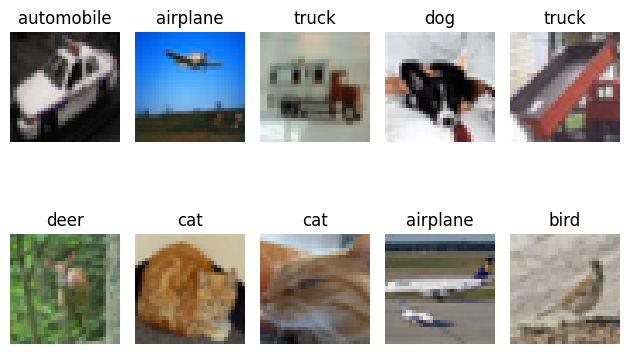

In [9]:
import matplotlib.pyplot as plt
import numpy as np

X_samples, y_samples = X_batch[:10].asnumpy().transpose(0, 2, 3, 1), np.argmax(y_batch[:10].asnumpy(), axis=1)
LABELS = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    axis.set_title(LABELS[y_samples[axis_idx]])
    axis.imshow(X_samples[axis_idx])
    axis.axis('off')
fig.tight_layout()
fig.show()

## Defining our neural network

Each image is $32 \times 32$ pixels with 3 channels per pixel \(RGB\). This implies a total of $32 \times 32 \times 3 = 3072$ input features per image. Since we have 10 categories of objects, let's define our model with a single fully connected layer with $3072$ input channels and $10$ output channels.

To fit the images into our neural network, we need to transform our images appropriately before passing them to our fully connected layer.

1. Use [`mindspore.ops.Flatten`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/ops/mindspore.ops.Flatten.html) to flatten our image before passing it to our fully connected layer

We'll also define hyper-parameters for fine-tuning our training process.

1. Learning rate $\eta$
1. Weight decay $\lambda$
1. Momentum $\mu$

In [10]:
import mindspore.nn as nn
import mindspore.ops as ops
from mindspore import dtype as mstype

class MyModel(nn.Cell):
    def __init__(self, eta=0.01, lambda_=0.0, mu=0.0):
        super().__init__()
        self.eta = eta
        self.lambda_ = lambda_
        self.mu = mu
        self.flatten = ops.Flatten()
        self.layer1 = nn.Dense(3072, 10, dtype=mstype.float16)

    def construct(self, X):
        X_flatten = self.flatten(X)
        y_hat = self.layer1(X_flatten)
        return y_hat

model = MyModel(eta=0.01)
model

MyModel(
  (layer1): Dense(input_channels=3072, output_channels=10, has_bias=True)
)

## Choosing our activation function, loss function and optimizer

Let's use the following activation function, loss function and optimizer.

1. Combined activation and loss function: [`mindspore.nn.SoftmaxCrossEntropyWithLogits`](https://www.mindspore.cn/docs/en/r2.8.0/api_python/nn/mindspore.nn.SoftmaxCrossEntropyWithLogits.html). This is especially suitable for classification tasks and has built-in safeguards against numeric overflow and underflow
1. Optimization algorithm: minibatch SGD

In [11]:
loss_fn = nn.SoftmaxCrossEntropyWithLogits(reduction='mean')
loss_fn

SoftmaxCrossEntropyWithLogits()

In [12]:
optimizer = nn.SGD(params=model.trainable_params(), learning_rate=model.eta, momentum=model.mu, weight_decay=model.lambda_)
optimizer

SGD()

## Defining our training and validation logic

Define our forward and gradient functions.

In [13]:
def forward(X, y):
    y_hat = model(X)
    loss = loss_fn(y_hat, y)
    return loss, y_hat

grad_fn = mindspore.value_and_grad(fn=forward, grad_position=None, weights=optimizer.parameters, has_aux=True)

Now define the training logic on a single batch and entire epoch.

In [14]:
def train_batch(X_batch, y_batch):
    (loss, _), grads = grad_fn(X_batch, y_batch)
    optimizer(grads)
    return loss

def train_epoch(epoch=0):
    print(f'Epoch {epoch} start')
    batch_count = train_ds.get_dataset_size()
    training_losses = []
    model.set_train()
    for batch_idx, (X_batch, y_batch) in enumerate(train_ds.create_tuple_iterator()):
        loss = train_batch(X_batch.astype(dtype=mstype.float16), y_batch.astype(dtype=mstype.float16))
        if batch_idx % 10 == 0:
            print(f'Training loss: {loss.asnumpy():.4f} [{batch_idx}/{batch_count}]')
        training_losses.append(loss)
    print(f'Epoch {epoch} end')
    return training_losses

Define our validation logic as well. Compute the validation loss after each epoch.

In [15]:
test_ds_sample_count = test_ds.get_dataset_size()
test_ds = test_ds.batch(batch_size=test_ds_sample_count)

def validate_epoch(epoch=0):
    model.set_train(False)
    X_test, y_test = next(test_ds.create_tuple_iterator())
    y_hat = model(X_test.astype(dtype=mstype.float16))
    validation_loss = loss_fn(y_hat, y_test.astype(dtype=mstype.float16))
    print(f'Validation loss after epoch {epoch}: {validation_loss.asnumpy():.4f}')
    return validation_loss

Train our model over 20 epochs.

In [16]:
training_losses = []
validation_losses = []
epochs = 20

In [17]:
print(f'Training our model for {epochs} epochs ...')

for epoch in range(epochs):
    training_losses.extend(train_epoch(epoch=epoch))
    validation_losses.append(validate_epoch(epoch=epoch))

training_losses, validation_losses = ops.stack(training_losses, axis=0), ops.stack(validation_losses, axis=0)
training_losses.shape, validation_losses.shape

Training our model for 20 epochs ...
Epoch 0 start


/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/c

.Training loss: 2.3516 [0/98]
Training loss: 2.2383 [10/98]
Training loss: 2.1816 [20/98]
Training loss: 2.1309 [30/98]
Training loss: 2.0938 [40/98]
Training loss: 2.1250 [50/98]
Training loss: 2.0781 [60/98]
Training loss: 1.9932 [70/98]
Training loss: 2.0312 [80/98]
Training loss: 2.0527 [90/98]
Epoch 0 end
Validation loss after epoch 0: 2.0215
Epoch 1 start
Training loss: 2.0273 [0/98]
Training loss: 1.9854 [10/98]
Training loss: 2.0000 [20/98]
Training loss: 1.9482 [30/98]
Training loss: 1.9316 [40/98]
Training loss: 1.9834 [50/98]
Training loss: 1.9814 [60/98]
Training loss: 1.9600 [70/98]
Training loss: 1.9883 [80/98]
Training loss: 1.9912 [90/98]
Epoch 1 end
Validation loss after epoch 1: 1.9551
Epoch 2 start
Training loss: 1.9229 [0/98]
Training loss: 1.9834 [10/98]
Training loss: 1.9219 [20/98]
Training loss: 1.9199 [30/98]
Training loss: 1.9580 [40/98]
Training loss: 1.9062 [50/98]
Training loss: 1.8838 [60/98]
Training loss: 1.9404 [70/98]
Training loss: 1.8691 [80/98]
Trai

((1960,), (20,))

Plot the training vs. validation losses with Matplotlib.

.

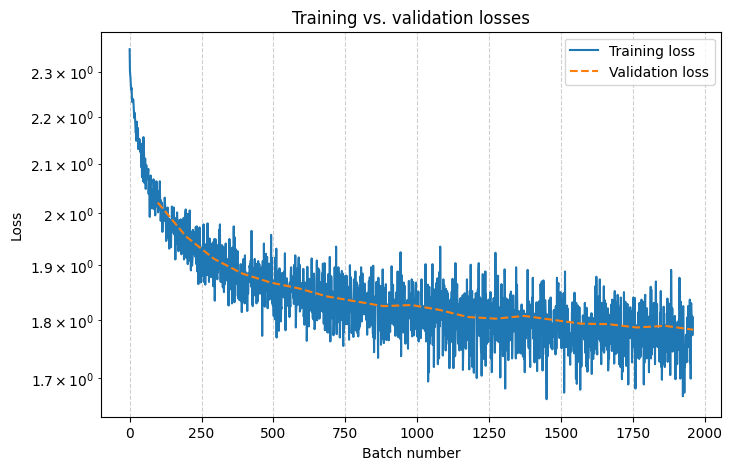

In [18]:
batches_per_epoch = 98
batches_x = np.arange(batches_per_epoch * epochs)
epochs_x = np.arange(epochs) * batches_per_epoch + batches_per_epoch
training_losses_y = training_losses.asnumpy()
validation_losses_y = validation_losses.asnumpy()

plt.figure(figsize=(8, 5))

plt.plot(batches_x, training_losses_y, label='Training loss', linestyle='-')
plt.plot(epochs_x, validation_losses_y, label='Validation loss', linestyle='--')

plt.title('Training vs. validation losses')
plt.xlabel('Batch number')
plt.ylabel('Loss')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

## Computing the model accuracy

Our trained model outputs raw logits so we need to convert it to a concrete category and compare it with the expected labels to compute the accuracy of our model. This is normally a 2-step process.

1. Apply softmax activation to convert the raw logits to predicted probabilities that sum up to $1$
1. Use `argmax` to select the most probable category from the given prediction

Fortunately, since softmax is monotonic and preserves ordering, we can skip \(1\) and apply `argmax` to the raw logits directly to achieve the same results.

In [19]:
X_test, y_test = next(test_ds.create_tuple_iterator())
X_test, y_test = X_test.astype(dtype=mstype.float16), ops.argmax(y_test.astype(dtype=mstype.float16), dim=1)
model.set_train(False)
y_hat = ops.argmax(model(X_test), dim=1)
total = test_ds_sample_count
correct = (y_hat == y_test).sum()
accuracy = (correct / total).item()
print(f'Validation accuracy: {accuracy:.4f}')

Validation accuracy: 0.3833


The validation accuracy of our trained model is between $25\%$ and $40\%$. This is expected since our model is a simple linear classification model with a single fully connected layer. The CIFAR-10 dataset is high-dimensional with many non-linear features that our simple linear classification model is unable to learn effectively - a textbook example of underfitting.

We shall revisit this dataset in future notebook experiments once we get to convolutional neural networks \(CNN\). CNNs learn non-linear features effectively and treat images as structured input instead of an unstructured, flattened layer of input features.

## Exporting our model to MindIR and ONNX formats

Let's use `mindspore.export` to export our model in MindIR format. This means we can publish our model to a model registry such as [ModelScope](https://modelscope.cn/home) or [Hugging Face](https://huggingface.co/) so others can download and use it to make predictions.

In [20]:
X_batch, _ = next(train_ds.create_tuple_iterator())
X_sample = X_batch[:1].astype(dtype=mstype.float16)
mindspore.export(model, X_sample, file_name='cifar10-linear-simple', file_format='MINDIR')
os.path.isfile('cifar10-linear-simple.mindir')

True

The same but in ONNX format with `mindspore.onnx.export`.

In [21]:
mindspore.onnx.export(model, X_sample, file_name='cifar10-linear-simple.onnx', input_names=['image'], output_names=['label'])
os.path.isfile('cifar10-linear-simple.onnx')

True

## Conclusion

We saw in this notebook experiment how to train a model for linear classification based on the CIFAR-10 dataset.